In [8]:
import sys
!{sys.executable} -m pip install liac-arff

  Using cached liac_arff-2.5.0-py3-none-any.whl



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import arff
import pandas as pd

with open('dataset.arff', 'r') as f:
    dataset = arff.load(f)

df = pd.DataFrame(
    dataset['data'],
    columns=[attr[0] for attr in dataset['attributes']]
)

print(df.head())

   No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    4.0   4.0   4.0   7.0  300.0  77.0  -0.7   
1   2  2013      3    1     1    8.0   8.0   4.0   7.0  300.0  77.0  -1.1   
2   3  2013      3    1     2    7.0   7.0   5.0  10.0  300.0  73.0  -1.1   
3   4  2013      3    1     3    6.0   6.0  11.0  11.0  300.0  72.0  -1.4   
4   5  2013      3    1     4    3.0   3.0  12.0  12.0  300.0  72.0  -2.0   

     PRES  DEWP  RAIN   wd  WSPM       station  
0  1023.0 -18.8   0.0  NNW   4.4  Aotizhongxin  
1  1023.2 -18.2   0.0    N   4.7  Aotizhongxin  
2  1023.5 -18.2   0.0  NNW   5.6  Aotizhongxin  
3  1024.5 -19.4   0.0   NW   3.1  Aotizhongxin  
4  1025.2 -19.5   0.0    N   2.0  Aotizhongxin  


In [6]:
import sys
!{sys.executable} -m pip install missingno


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys
!{sys.executable} -m pip install prophet

  Using cached prophet-1.3.0-py3-none-win_amd64.whl.metadata (3.6 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached holidays-0.97-py3-none-any.whl.metadata (53 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-win_amd64.whl (12.1 MB)
Using cached holidays-0.97-py3-none-any.whl (1.5 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------------- -------------------------- 2/6 [importlib_resources]
   ------------- -------------------------- 2/6 [importlib_resources]
   ------------- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series specific plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Statistical tests for stationarity
from statsmodels.tsa.stattools import adfuller, kpss

# Classical time series models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB


In [5]:
#missing values number
df.isnull().sum()

No             0
year           0
month          0
day            0
hour           0
PM2.5       8739
PM10        6449
SO2         9021
NO2        12116
CO         20701
O3         13277
TEMP         398
PRES         393
DEWP         403
RAIN         390
wd          1822
WSPM         318
station        0
dtype: int64

<Axes: >

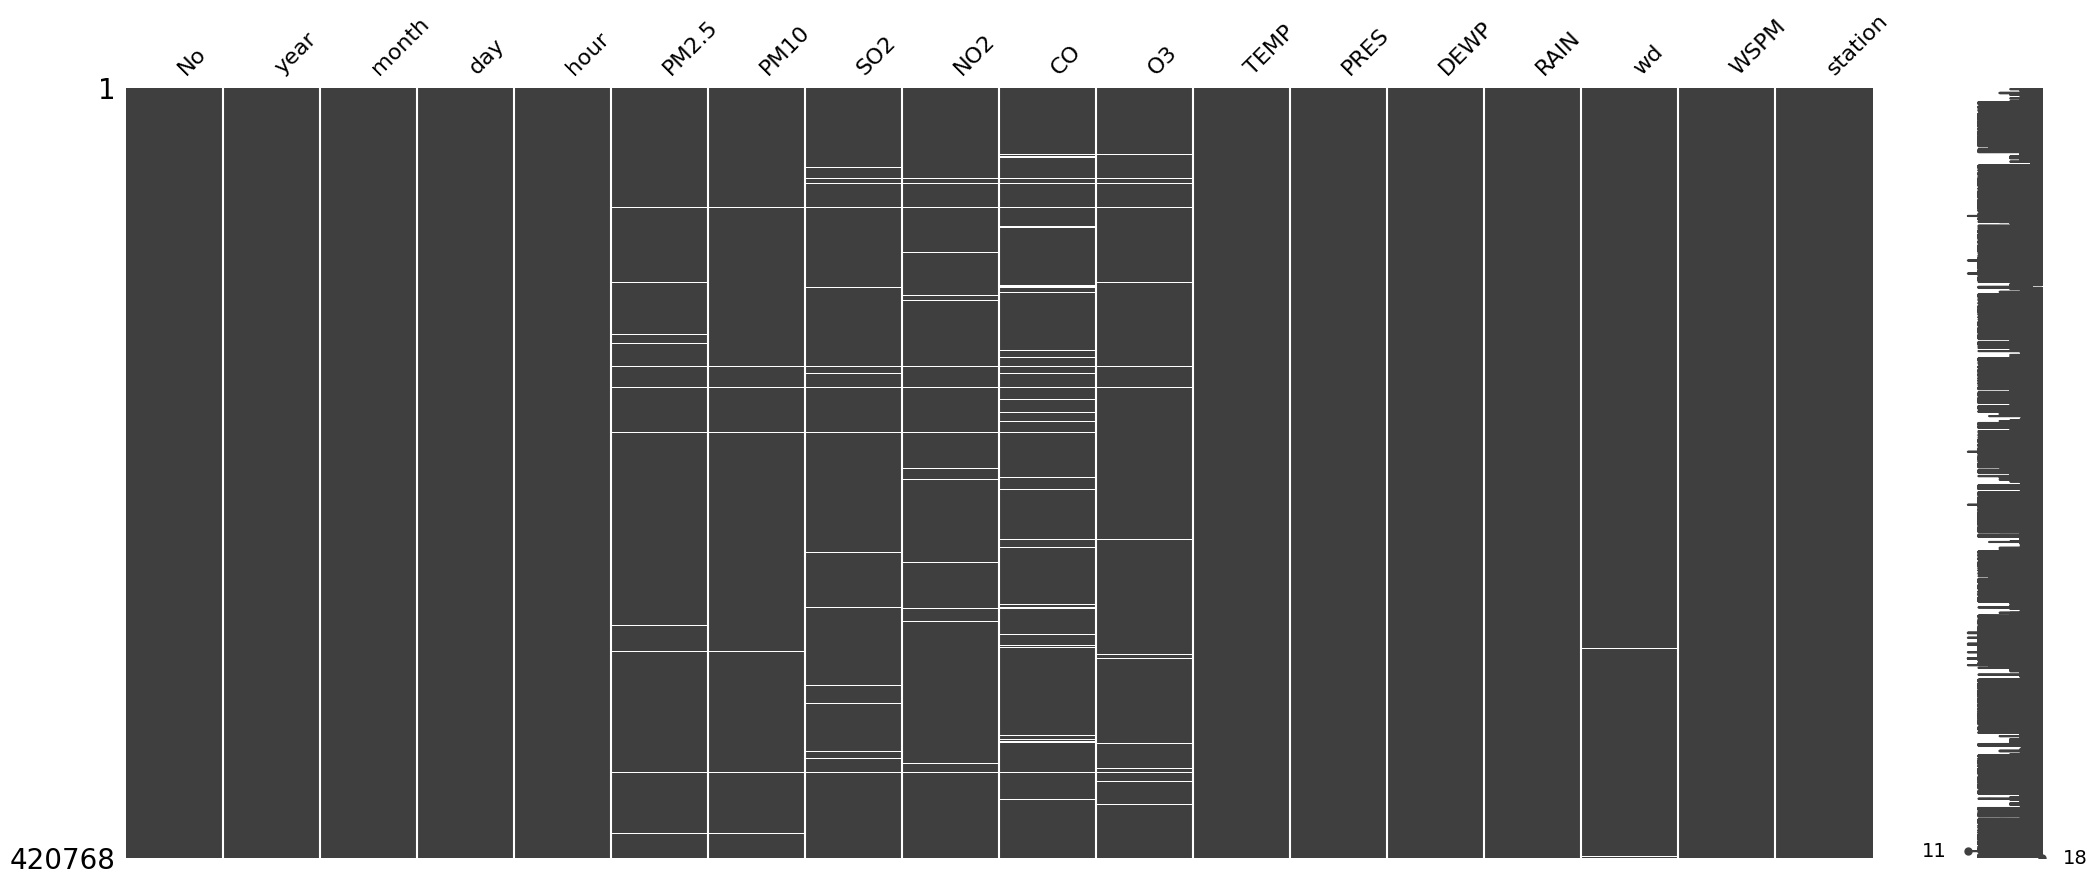

In [6]:
# visualize missing values
import missingno as msno    
msno.matrix(df)

In [7]:
#summary statistics
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


In [3]:
# Identify numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Make a copy to be safe
df_clean = df.copy()

In [4]:
# Fill missing values for numeric columns (forward + backward fill)
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(method='ffill').fillna(method='bfill')

# Fill missing values for categorical columns
df_clean['wd'] = df_clean['wd'].fillna(method='ffill')

C:\Users\HP\AppData\Local\Temp\ipykernel_16776\1069455724.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[numeric_cols] = df_clean[numeric_cols].fillna(method='ffill').fillna(method='bfill')
C:\Users\HP\AppData\Local\Temp\ipykernel_16776\1069455724.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean['wd'] = df_clean['wd'].fillna(method='ffill')


In [5]:
#check missing values after imputation
df_clean.isnull().sum()

No         0
year       0
month      0
day        0
hour       0
PM2.5      0
PM10       0
SO2        0
NO2        0
CO         0
O3         0
TEMP       0
PRES       0
DEWP       0
RAIN       0
wd         0
WSPM       0
station    0
dtype: int64

## Feature Engineering

In [19]:
# combine year , month , day and hour into a single datetime column 
df_clean['datetime'] = pd.to_datetime(df_clean[['year', 'month', 'day', 'hour']])

In [20]:
#sort by datetime(Important in time series)
df_clean = df_clean.sort_values('datetime').reset_index(drop=True)

In [21]:
# set datetime as index
df_clean.set_index('datetime', inplace=True)

In [22]:
df_clean.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,...,PM2.5_lag_15,PM2.5_lag_16,PM2.5_lag_17,PM2.5_lag_18,PM2.5_lag_19,PM2.5_lag_20,PM2.5_lag_21,PM2.5_lag_22,PM2.5_lag_23,PM2.5_lag_24
datetime,,,,,,,,,,,,,,,,,,,,,
2013-03-01 02:00:00,3,2013,3,1,2,4.0,4.0,3.0,2.0,100.0,...,6.0,7.0,9.0,5.0,3.0,3.0,8.0,4.0,6.0,4.0
2013-03-01 02:00:00,3,2013,3,1,2,3.0,6.0,6.0,19.0,400.0,...,6.0,3.0,11.0,4.0,6.0,12.0,4.0,4.0,8.0,9.0
2013-03-01 02:00:00,3,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,...,3.0,11.0,4.0,6.0,12.0,4.0,4.0,8.0,9.0,4.0
2013-03-01 02:00:00,3,2013,3,1,2,7.0,7.0,3.0,17.0,300.0,...,11.0,4.0,6.0,12.0,4.0,4.0,8.0,9.0,4.0,6.0
2013-03-01 02:00:00,3,2013,3,1,2,14.0,14.0,3.0,7.0,200.0,...,6.0,12.0,4.0,4.0,8.0,9.0,4.0,6.0,7.0,9.0


## check the numerical features using plots

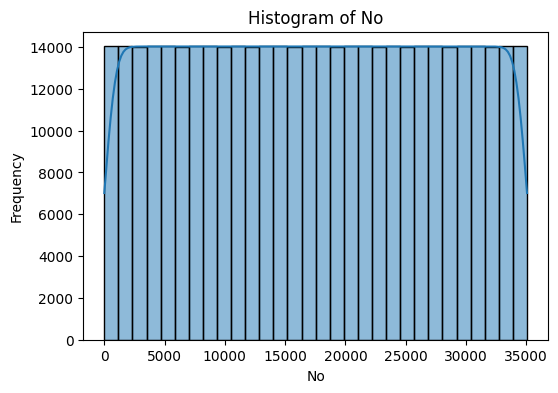

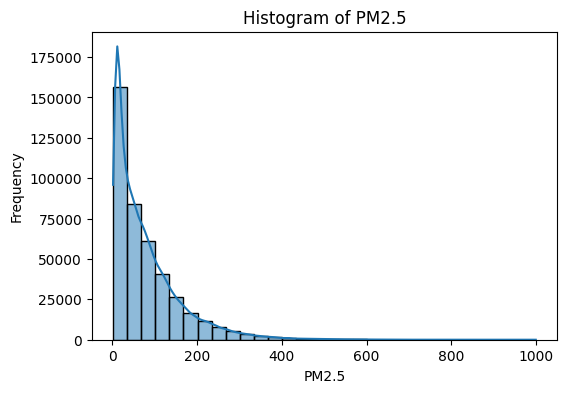

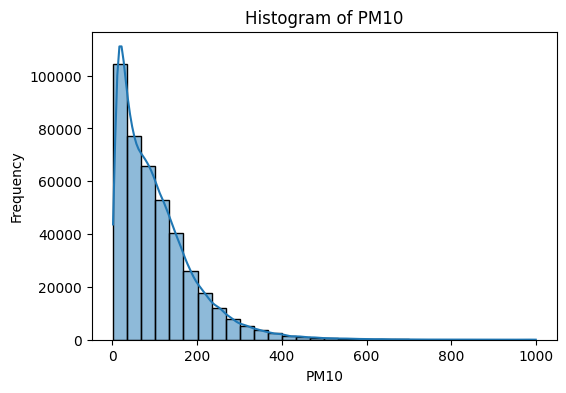

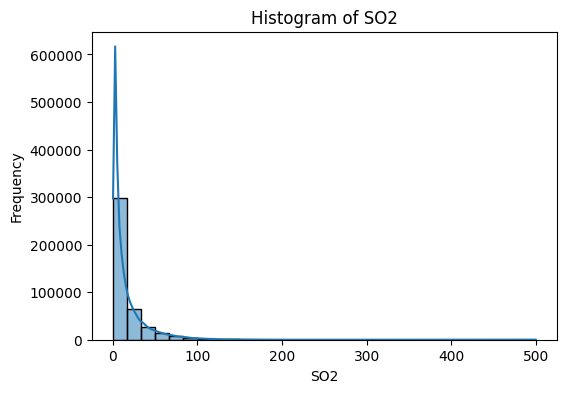

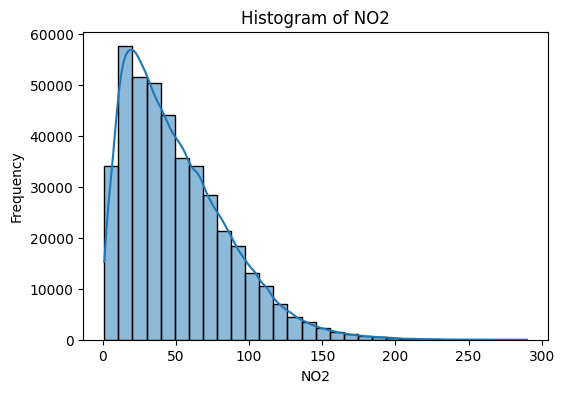

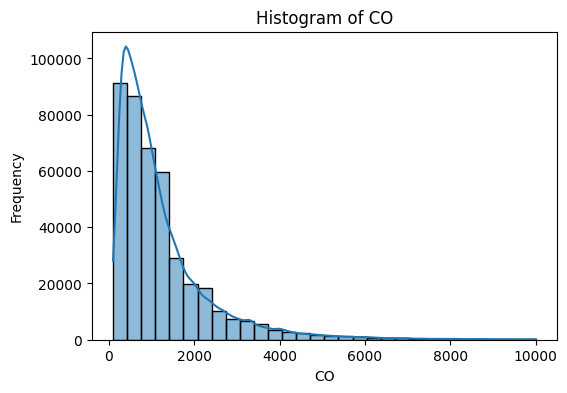

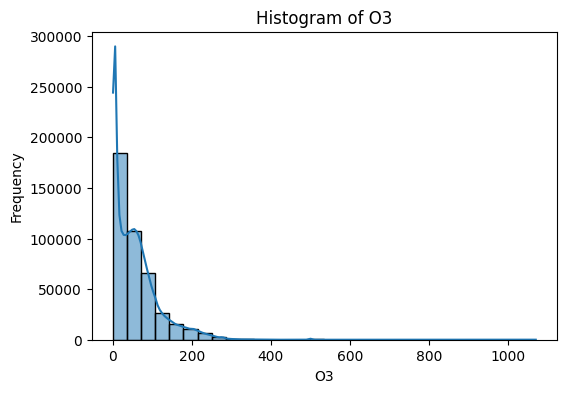

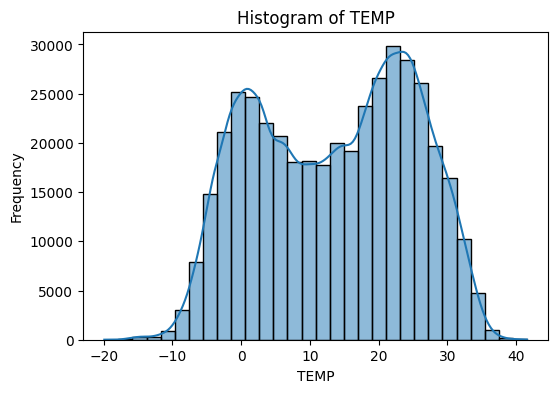

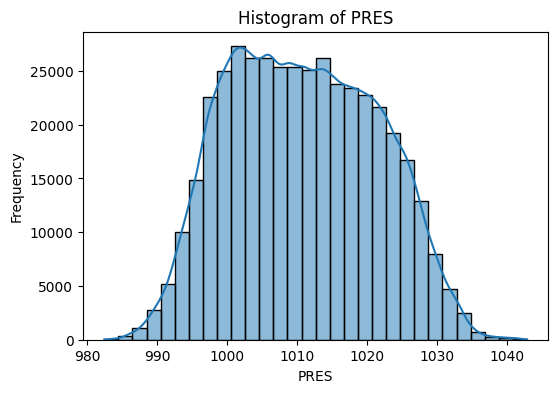

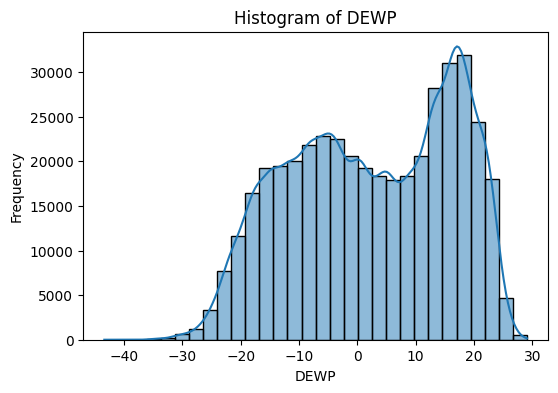

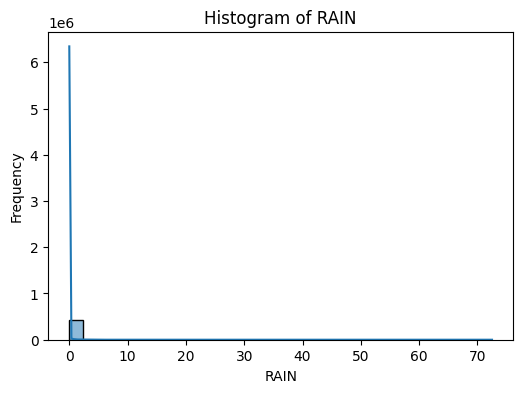

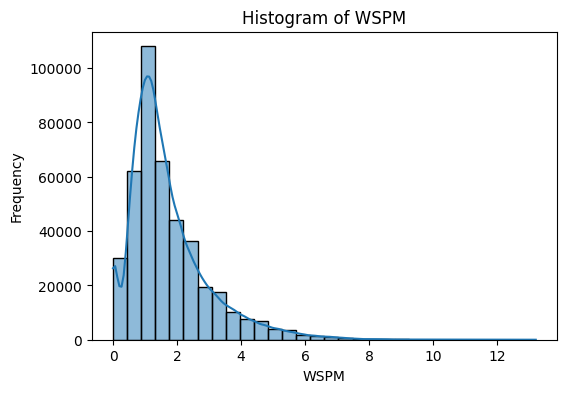

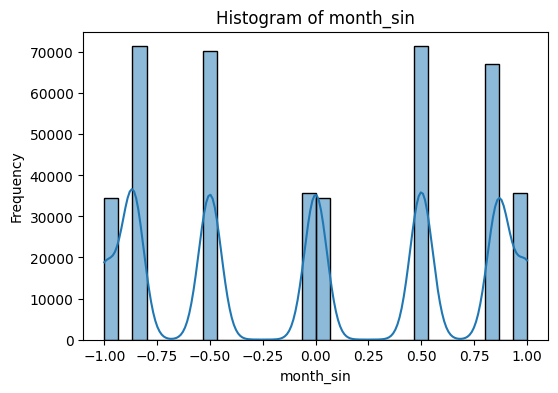

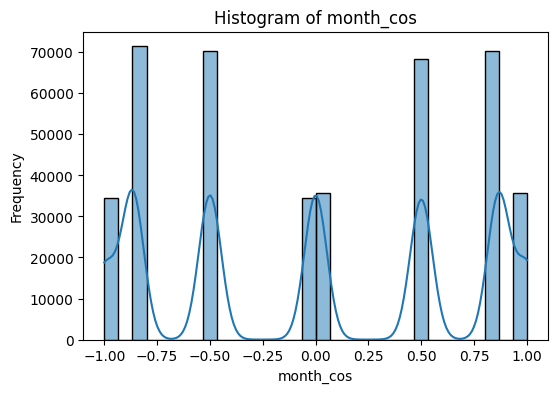

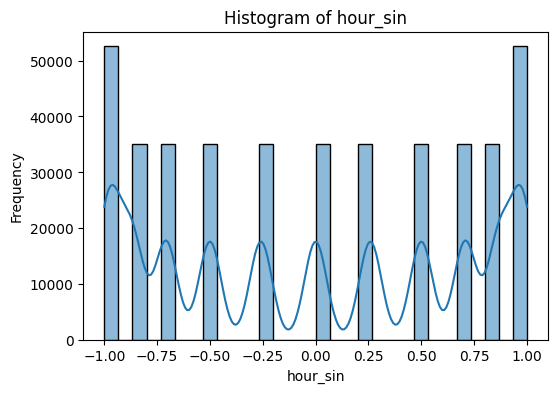

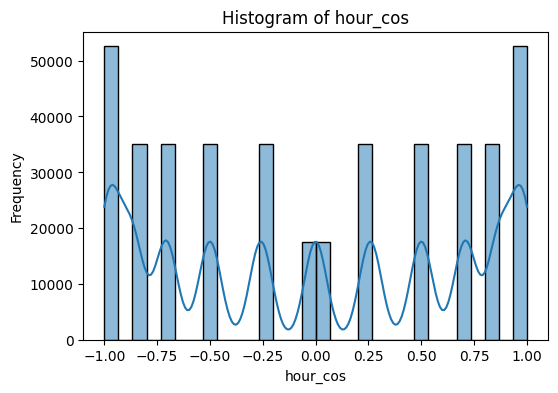

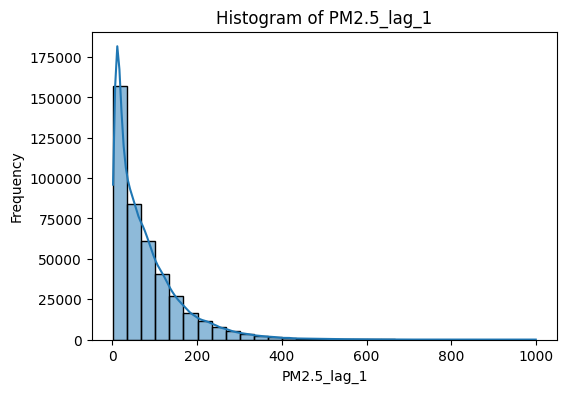

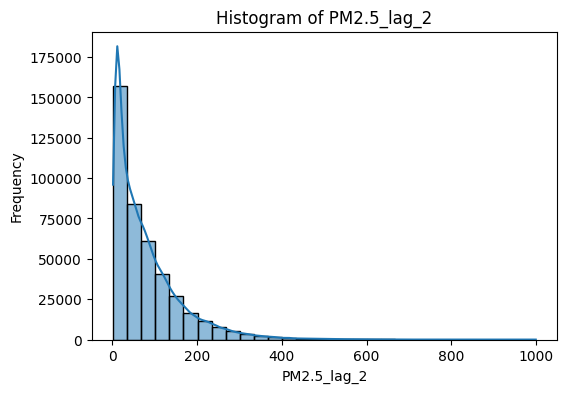

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# exclude date/time related columns
exclude_cols = ['year', 'month', 'day', 'hour', 'datetime']

# select numerical columns only
num_cols = [
    col for col in df_clean.select_dtypes(include=['int64', 'float64']).columns
    if col not in exclude_cols
]

# plot histograms one by one
for col in num_cols:
    plt.figure(figsize=(6,4))
    
    sns.histplot(df_clean[col], bins=30, kde=True)
    
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    
    plt.show()

In [24]:
# time based features(captures seasonal and temporal patterns)
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean.index.month / 12)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean.index.month / 12)
df_clean['hour_sin'] = np.sin(2 * np.pi * df_clean.index.hour / 24)
df_clean['hour_cos'] = np.cos(2 * np.pi * df_clean.index.hour / 24)

In [25]:
#lag features for target variable (PM2.5)(helps the model remember past values-pollution levels )
for lag in range(1, 25):  # create lag features for the past 24 hours
    df_clean[f'PM2.5_lag_{lag}'] = df_clean['PM2.5'].shift(lag)

In [26]:
# drop missing rows caused by lag creation
df_clean = df_clean.dropna().reset_index(drop=True)

## Time Series Exploration Trend,Stationarity and Seasonality

In [27]:
print(df_clean.columns)

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station',
       'month_sin', 'month_cos', 'hour_sin', 'hour_cos', 'PM2.5_lag_1',
       'PM2.5_lag_2', 'PM2.5_lag_3', 'PM2.5_lag_4', 'PM2.5_lag_5',
       'PM2.5_lag_6', 'PM2.5_lag_7', 'PM2.5_lag_8', 'PM2.5_lag_9',
       'PM2.5_lag_10', 'PM2.5_lag_11', 'PM2.5_lag_12', 'PM2.5_lag_13',
       'PM2.5_lag_14', 'PM2.5_lag_15', 'PM2.5_lag_16', 'PM2.5_lag_17',
       'PM2.5_lag_18', 'PM2.5_lag_19', 'PM2.5_lag_20', 'PM2.5_lag_21',
       'PM2.5_lag_22', 'PM2.5_lag_23', 'PM2.5_lag_24'],
      dtype='object')


In [34]:
# create datetime column
df_clean['datetime'] = pd.to_datetime(
    df_clean[['year', 'month', 'day', 'hour']]
)

# filter station
station_1 = df_clean[df_clean['station'] == 'Gucheng']

# set datetime as index
station_1.set_index('datetime', inplace=True)

# sort index
station_1.sort_index(inplace=True)

# basic info
print(station_1[target].describe())

count    35060.000000
mean        84.354170
std         83.229398
min          2.000000
25%         24.000000
50%         60.000000
75%        116.000000
max        770.000000
Name: PM2.5, dtype: float64


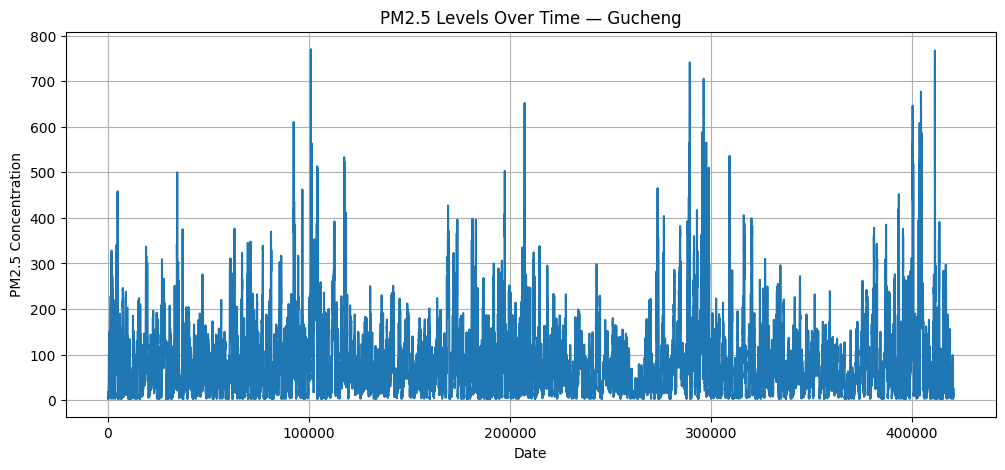

In [ ]:
#plot PM2.5 levels over time

plt.figure(figsize=(12,5))
plt.plot(df.station_1.index, df.station_1['PM2.5'])
plt.title(f'PM2.5 Levels Over Time — {station_name}')
plt.xlabel('Date')
plt.ylabel('PM2.5 Concentration')
plt.grid(True)
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_16776\2850556086.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_avg = station_1['PM2.5'].resample('M').mean()


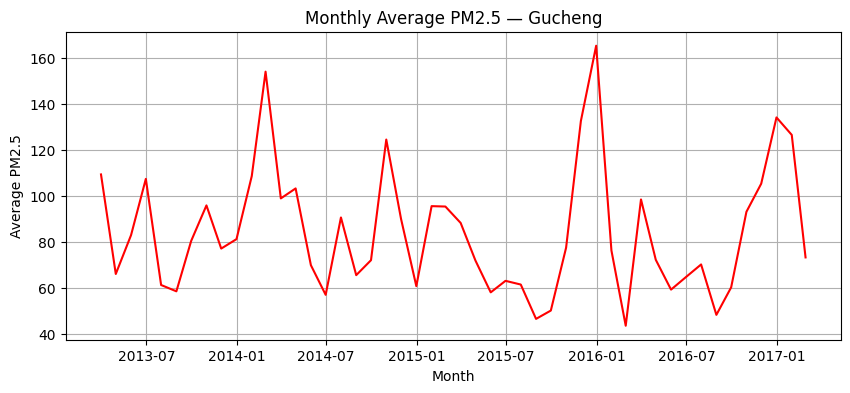

In [38]:
monthly_avg = station_1['PM2.5'].resample('M').mean()

plt.figure(figsize=(10,4))
plt.plot(monthly_avg, color='red')
plt.title(f'Monthly Average PM2.5 — {station_name}')
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.grid(True)
plt.show()

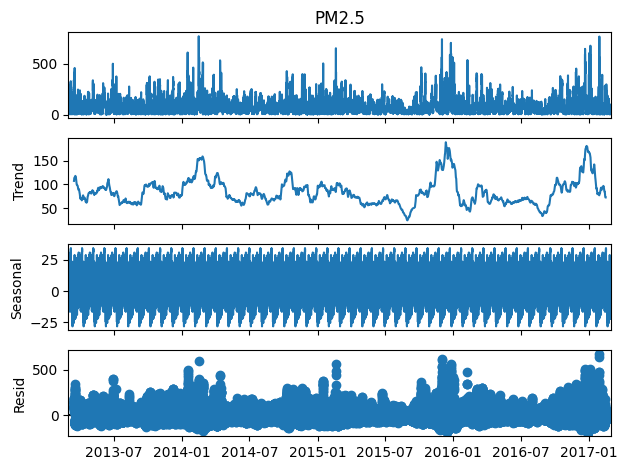

In [41]:
# Decompse time series
from scipy.__config__ import show
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(station_1['PM2.5'].dropna(), model='additive', period=24*30) # Assuming daily seasonality
decomposition.plot()
plt.show()

In [43]:
#Check stationarity using ADF test

from statsmodels.tsa.stattools import adfuller
result = adfuller(station_1['PM2.5'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] < 0.05:
    print("The time series is stationary(no differencing needed).")
else:
    print("The time series is non-stationary(needs differencing)") 

ADF Statistic: -18.84610070924646
p-value: 0.0
The time series is stationary(no differencing needed).


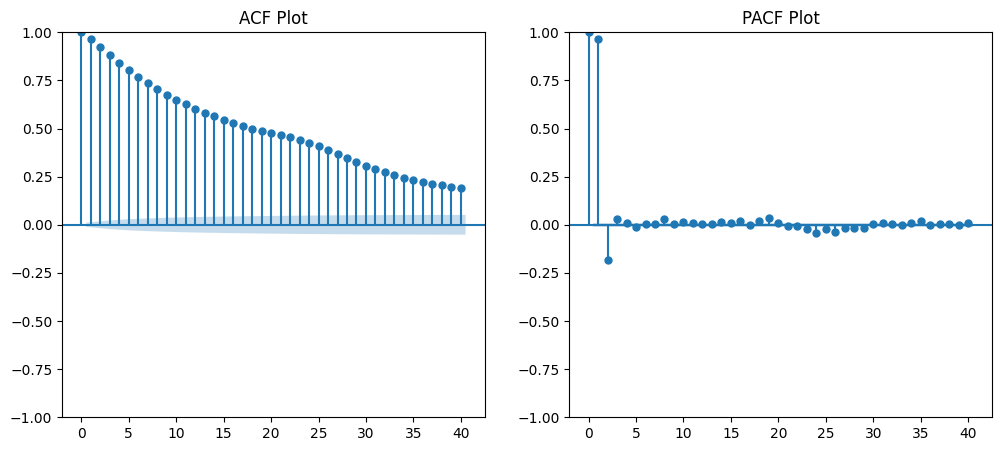

In [44]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_acf(station_1['PM2.5'].dropna(), lags=40, ax=plt.gca())
plt.title('ACF Plot')

plt.subplot(1,2,2)
plot_pacf(station_1['PM2.5'].dropna(), lags=40, ax=plt.gca())
plt.title('PACF Plot')

plt.show()

ACF plot

slow decay shows the series is non stationary- it has a trend or long term dependacy

data points show high correlation with their past values suggesting trend persistence.

PACF Plot

significant spike only at lag 1 suggests the series follows AR(1)pattern - each value mainly depends on its immediate previous value

In [46]:
#split data into train and test sets
#ensure datetime order is maintained (no shuffling)
station_1 = station_1.sort_index()

# split 80% train and 20% test
split_index = int(len(station_1) * 0.8)
train_size = int (len(station_1) * 0.8)
train = station_1.iloc[:train_size]
test = station_1.iloc[train_size:]

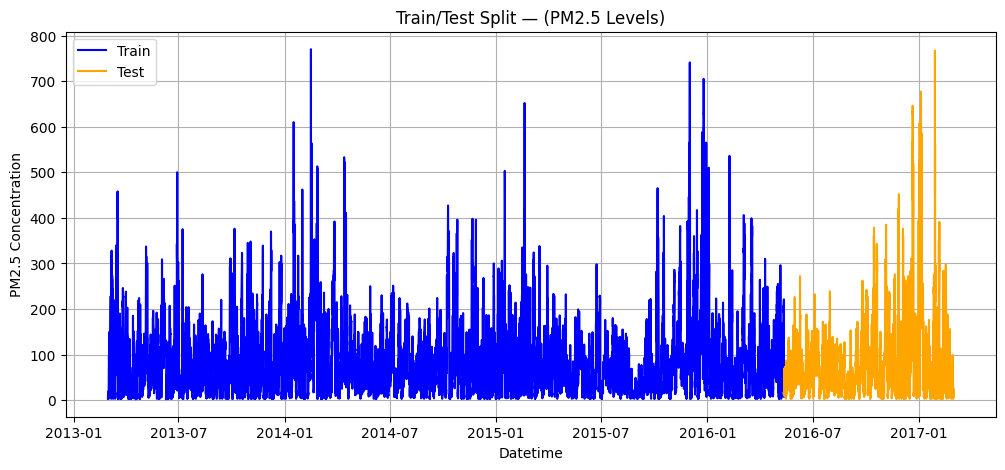

In [47]:
# visualize train and test split
plt.figure(figsize=(12,5))
plt.plot(train.index, train['PM2.5'], label='Train', color='blue')
plt.plot(test.index, test['PM2.5'], label='Test', color='orange')

plt.title(f'Train/Test Split — (PM2.5 Levels)') 
plt.xlabel('Datetime')
plt.ylabel('PM2.5 Concentration')
plt.legend()
plt.grid(True)  
plt.show()


In [48]:
#fit the ARIMA model on training set

model = ARIMA(train['PM2.5'], order=(1,1,1))
fitted_model = model.fit()

#forecast on test set
forecast = fitted_model.forecast(steps=len(test))


c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [50]:
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  PM2.5   No. Observations:                28048
Model:                 ARIMA(1, 1, 1)   Log Likelihood             -125394.962
Date:                Tue, 26 May 2026   AIC                         250795.925
Time:                        22:26:47   BIC                         250820.650
Sample:                    03-01-2013   HQIC                        250803.884
                         - 05-12-2016                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0517      0.013     -4.017      0.000      -0.077      -0.026
ma.L1          0.2001      0.013     15.906      0.000       0.175       0.225
sigma2       447.7149      0.664    674.449      0.000     446.414     449.016
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           6710632.96
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               0.65   Skew:                            -1.90
Prob(H) (two-sided):                  0.00   Kurtosis:                        78.68
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

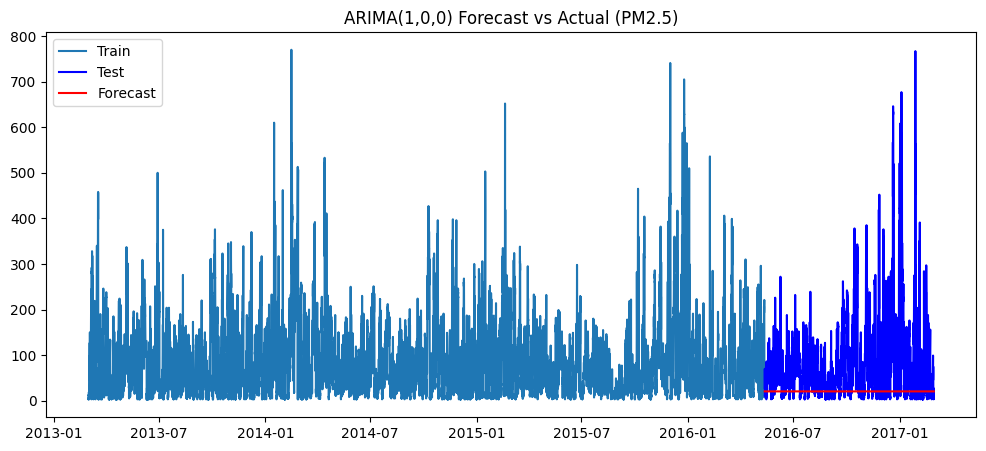

In [51]:
#compare actual vs predicted
plt.figure(figsize=(12,5))
plt.plot(train['PM2.5'], label='Train')
plt.plot(test['PM2.5'], label='Test', color='blue')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.legend()
plt.title('ARIMA(1,0,0) Forecast vs Actual (PM2.5)')
plt.show()

In [52]:
#Evaluate model performance

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test['PM2.5'], forecast))
mae = mean_absolute_error(test['PM2.5'], forecast)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")

RMSE: 110.18
MAE: 68.24


In [53]:
# Prepare Prophet dataframe
prophet_df = train.reset_index()[['datetime', 'PM2.5']].rename(columns={'datetime': 'ds', 'PM2.5': 'y'})

In [54]:

prophet_model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.5
)

prophet_model.fit(prophet_df)

22:29:08 - cmdstanpy - INFO - Chain [1] start processing
22:29:35 - cmdstanpy - INFO - Chain [1] done processing


In [55]:
# forecast on test period
# Create future dataframe for test period
future = prophet_model.make_future_dataframe(periods=len(test), freq='H')

# Forecast
forecast = prophet_model.predict(future)

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [57]:
# evaluate performance 
#extract forecasted values for test set
prophet_forecast = forecast.set_index('ds').loc[test.index]['yhat']

#evaluation metrics
mae_prophet = mean_absolute_error(test['PM2.5'], prophet_forecast)
rmse_prophet = np.sqrt(mean_squared_error(test['PM2.5'], prophet_forecast))

print(f"Prophet RMSE: {rmse_prophet:.2f}")
print(f"Prophet MAE: {mae_prophet:.2f}")

Prophet RMSE: 117.20
Prophet MAE: 97.96


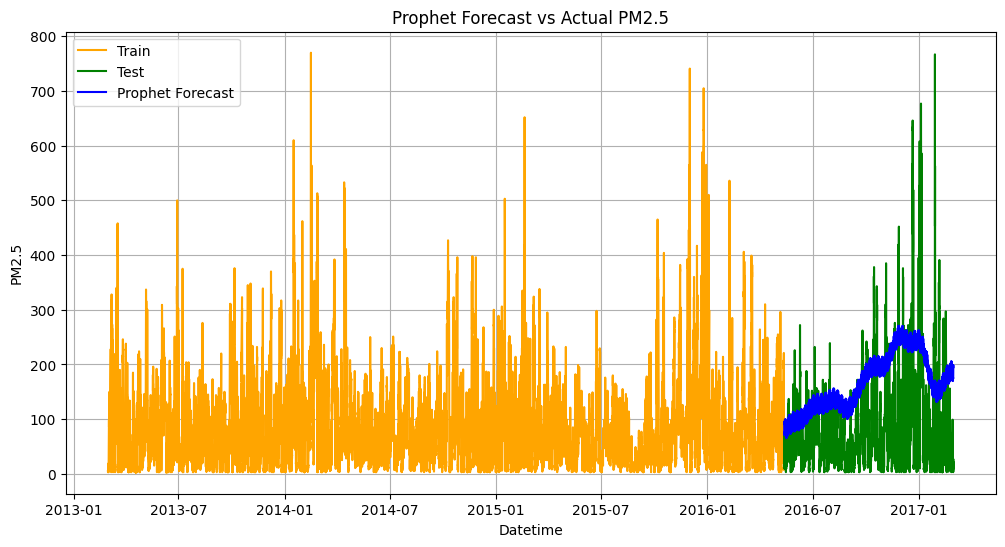

In [59]:
#visualize predictions vs actual
plt.figure(figsize = (12,6))
plt.plot(train.index, train['PM2.5'], label='Train', color='orange')
plt.plot(test.index, test['PM2.5'], label='Test', color='green')
plt.plot(prophet_forecast.index, prophet_forecast, label='Prophet Forecast', color='blue')

plt.title('Prophet Forecast vs Actual PM2.5')
plt.xlabel('Datetime')
plt.ylabel('PM2.5')
plt.legend()
plt.grid(True)
plt.show()

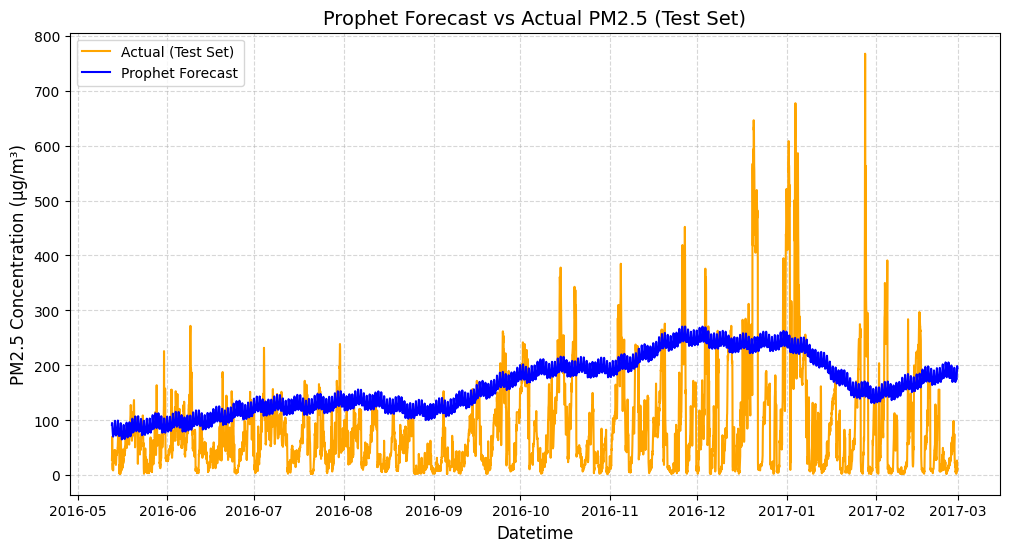

In [61]:

plt.figure(figsize=(12,6))

# Plot only test data and Prophet forecast
plt.plot(test.index, test['PM2.5'], label='Actual (Test Set)', color='orange')
plt.plot(prophet_forecast.index, prophet_forecast, label='Prophet Forecast', color='blue')

plt.title('Prophet Forecast vs Actual PM2.5 (Test Set)', fontsize=14)
plt.xlabel('Datetime', fontsize=12)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()